In [1]:
import random
import sys
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import DecisionTreeClassifier


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("matplotlib  ", matplotlib.__version__)
print("torch       ", torch.__version__)

python       3.13.2
numpy        2.2.3
pandas       2.2.3
scikit-learn 1.7.1
matplotlib   3.10.1
torch        2.14.0+cpu


In [2]:
DATA_DIR = Path(".")
train = pd.read_csv(DATA_DIR / "train.csv")
validation = pd.read_csv(DATA_DIR / "validation.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

feature_columns = [
    column
    for column in train.columns
    if column not in {"row_id", "target"}
]

validation_features = [
    column
    for column in validation.columns
    if column not in {"row_id", "target"}
]

test_features = [
    column
    for column in test.columns
    if column != "row_id"
]

assert feature_columns == validation_features == test_features

X_train = train[feature_columns]
y_train = train["target"]

X_validation = validation[feature_columns]
y_validation = validation["target"]

X_test = test[feature_columns]

In [3]:
test.head()

,row_id,f0000,f0001,f0002,f0003,f0004,f0005,f0006,f0007,f0008,...,f0502,f0503,f0504,f0505,f0506,f0507,f0508,f0509,f0510,f0511
0,row_46ad1afad8562239f79c,0.244810,0.114570,0.007334,0.023760,0.387686,0.149363,0.945092,0.013998,0.000000,...,0.275527,0.248542,0.292501,0.260105,0.075953,0.119261,0.098756,0.215996,0.578230,0.000233
1,row_b42ade9cd57b8d919acb,1.896484,0.131558,0.095100,0.102150,0.008930,0.092205,0.130427,0.019269,0.700132,...,0.078451,0.094636,0.127212,0.052143,0.707156,0.747834,0.129984,0.242671,0.692840,0.194765
2,row_c951cd5e197b6b4e8b83,1.521355,0.284507,0.409720,0.207996,0.011174,1.192619,0.790904,0.139842,0.120414,...,0.273042,0.075460,0.864784,0.563859,0.148395,0.194541,0.161783,0.412439,1.115551,0.059842
3,row_a54b3423760d599416ce,2.427760,0.875640,1.255399,0.113083,0.182349,1.190072,1.121677,0.397405,0.631804,...,2.586512,1.683931,1.133419,1.548128,0.126427,7.058036,0.229949,0.278353,3.893234,0.067383
4,row_a87c87cc47690e2a303f,1.392432,0.120985,0.118925,0.568936,0.293686,0.628145,0.508286,0.019553,0.445561,...,0.413616,0.258653,0.265331,0.161138,0.068309,1.087377,0.058649,0.169336,0.004852,0.056881


## Модели

Гиперпараметры дерева и случайного леса были подобраны ранее через `GridSearchCV` (5-fold CV на train, метрика ROC-AUC):
- дерево — перебор `max_depth` 8–12, `max_features` 0.4–0.6, `min_samples_leaf` 16–28, `min_samples_split` 2/5/10;
- лес — перебор `max_features` 0.1–0.3 при 1000 деревьев.

Сам перебор убран из ноутбука, чтобы Run All шёл быстрее; ниже обучаются только найденные конфигурации. Все результаты собираются в таблицу экспериментов.

In [4]:
EXPERIMENTS = []

def log_experiment(name, fit_fn, score_fn, features="raw 512", seed=SEED):
    t0 = time.perf_counter()
    fit_fn()
    fit_sec = time.perf_counter() - t0
    scores = score_fn()
    auc = roc_auc_score(y_validation, scores)
    EXPERIMENTS.append(dict(model=name, features=features,
                            val_roc_auc=round(auc, 4),
                            fit_sec=round(fit_sec, 1), seed=seed))
    return scores

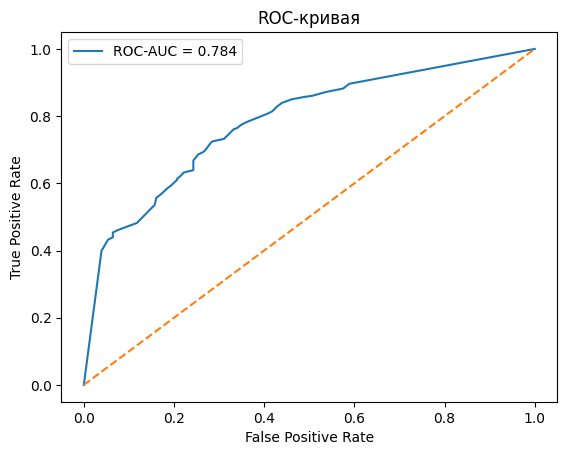

In [5]:
BestTreeModel = DecisionTreeClassifier(criterion='gini',max_depth=10,min_samples_leaf=20,min_samples_split=2,max_features=0.5,random_state=SEED)
#параметры были найдены через GridSearchCV
probabilities = p_tree = log_experiment(
    "DecisionTree",
    lambda: BestTreeModel.fit(X_train, y_train),
    lambda: BestTreeModel.predict_proba(X_validation)[:, 1],
)
fpr, tpr, thresholds = roc_curve(y_validation, probabilities)
auc = roc_auc_score(y_validation, probabilities)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

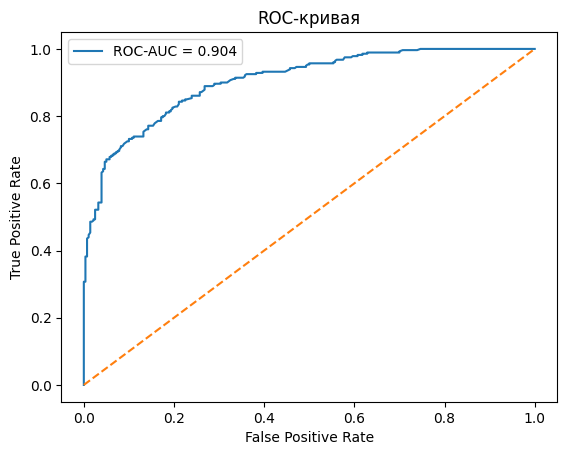

In [6]:
BestRandForest = RandomForestClassifier(n_estimators=1000,criterion='gini',max_depth=None,min_samples_leaf=1,min_samples_split=2,max_features=0.15,random_state=SEED)
#параметры были найдены через GridSearchCV
probabilities = p_rf = log_experiment(
    "RandomForest",
    lambda: BestRandForest.fit(X_train, y_train),
    lambda: BestRandForest.predict_proba(X_validation)[:, 1],
)
fpr, tpr, thresholds = roc_curve(y_validation, probabilities)
auc = roc_auc_score(y_validation, probabilities)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

Случайный лес заметно лучше одиночного дерева (точные значения — в таблице экспериментов), поэтому можно перейти к градиентному бустингу.

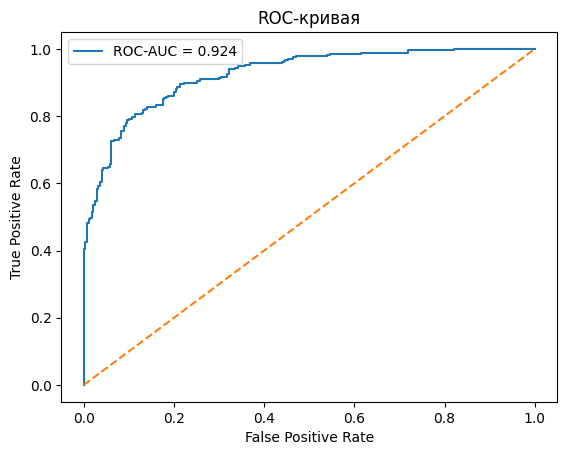

In [7]:
BestGradientBoost = GradientBoostingClassifier(n_estimators=600,max_depth=5,learning_rate=0.15, random_state=SEED)
#параметры (600 деревьев, глубина 5, lr 0.15) подобраны вручную по validation
probabilities = p_gb = log_experiment(
    "GradientBoosting",
    lambda: BestGradientBoost.fit(X_train, y_train),
    lambda: BestGradientBoost.predict_proba(X_validation)[:, 1],
)
fpr, tpr, thresholds = roc_curve(y_validation, probabilities)
auc = roc_auc_score(y_validation, probabilities)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

In [8]:
for w in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = w * p_rf + (1 - w) * p_gb
    print(w, roc_auc_score(y_validation, p))

0.2 0.9185969387755102
0.3 0.9184693877551019
0.4 0.9181377551020408
0.5 0.9176147959183674
0.6 0.9169260204081633
0.7 0.9160204081632652
0.8 0.9147831632653061


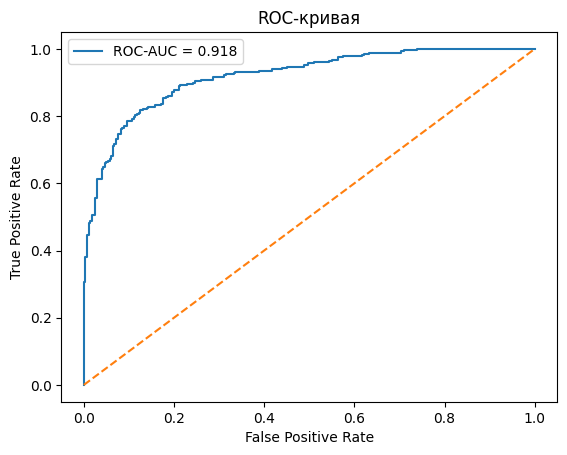

In [9]:
w = 0.3
fpr, tpr, thresholds = roc_curve(y_validation, w * p_rf + (1 - w) * p_gb)
auc = roc_auc_score(y_validation, w * p_rf + (1 - w) * p_gb)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

In [10]:
extra = ExtraTreesClassifier(
    n_estimators=1000,
    max_features=0.2,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=SEED,
    n_jobs=-1
)

p_extra = log_experiment(
    "ExtraTrees",
    lambda: extra.fit(X_train, y_train),
    lambda: extra.predict_proba(X_validation)[:, 1],
)

print(
    "ExtraTrees:",
    roc_auc_score(y_validation, p_extra)
)

ExtraTrees: 0.9218686224489796


In [11]:
for w_rf in [0, 0.1, 0.2, 0.3]:
    for w_extra in [0, 0.1, 0.2, 0.3]:
        
        w_gb = 1 - w_rf - w_extra
        
        if w_gb < 0:
            continue
        
        p = (
            w_gb * p_gb +
            w_rf * p_rf +
            w_extra * p_extra
        )
        
        score = roc_auc_score(y_validation, p)
        
        print(
            f"GB={w_gb:.1f}, RF={w_rf:.1f}, "
            f"Extra={w_extra:.1f}: {score:.5f}"
        )

GB=1.0, RF=0.0, Extra=0.0: 0.92412
GB=0.9, RF=0.0, Extra=0.1: 0.92598
GB=0.8, RF=0.0, Extra=0.2: 0.92612
GB=0.7, RF=0.0, Extra=0.3: 0.92667
GB=0.9, RF=0.1, Extra=0.0: 0.91936
GB=0.8, RF=0.1, Extra=0.1: 0.92286
GB=0.7, RF=0.1, Extra=0.2: 0.92450
GB=0.6, RF=0.1, Extra=0.3: 0.92540
GB=0.8, RF=0.2, Extra=0.0: 0.91860
GB=0.7, RF=0.2, Extra=0.1: 0.92149
GB=0.6, RF=0.2, Extra=0.2: 0.92335
GB=0.5, RF=0.2, Extra=0.3: 0.92412
GB=0.7, RF=0.3, Extra=0.0: 0.91847
GB=0.6, RF=0.3, Extra=0.1: 0.92077
GB=0.5, RF=0.3, Extra=0.2: 0.92213
GB=0.4, RF=0.3, Extra=0.3: 0.92250


In [12]:
for w in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    p = w * p_gb + (1 - w) * p_extra
    
    score = roc_auc_score(y_validation, p)
    
    print(
        f"GB={w:.2f}, "
        f"Extra={1-w:.2f}: "
        f"{score:.6f}"
    )

GB=0.55, Extra=0.45: 0.927270
GB=0.60, Extra=0.40: 0.927015
GB=0.65, Extra=0.35: 0.926760
GB=0.70, Extra=0.30: 0.926671
GB=0.75, Extra=0.25: 0.926441
GB=0.80, Extra=0.20: 0.926122


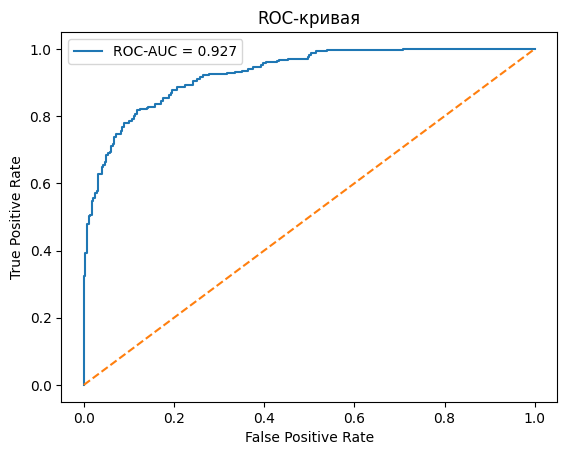

In [13]:
p = 0.55 * p_gb + 0.45 * p_extra

fit_sec = {e["model"]: e["fit_sec"] for e in EXPERIMENTS}
EXPERIMENTS.append(dict(model="Blend 0.55·GB + 0.45·ET", features="raw 512",
                        val_roc_auc=round(roc_auc_score(y_validation, p), 4),
                        fit_sec=round(fit_sec["GradientBoosting"] + fit_sec["ExtraTrees"], 1),
                        seed=SEED))

fpr, tpr, thresholds = roc_curve(y_validation, p)
auc = roc_auc_score(y_validation, p)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

## SVM с RBF-ядром (дополнительная модель)

In [14]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

svc = SVC(C=3, gamma="scale")   # БЕЗ StandardScaler — все признаки в одних единицах
p_svc = log_experiment("SVC (RBF, C=3)",
                       lambda: svc.fit(X_train, y_train),
                       lambda: svc.decision_function(X_validation),
                       seed=None)   # SVC без probability=True детерминирован

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_auc = cross_val_score(SVC(C=3, gamma="scale"), X_train, y_train,
                         cv=cv, scoring="roc_auc")
print(f"SVC CV ROC-AUC на train: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

SVC CV ROC-AUC на train: 0.9316 ± 0.0037


## Дополнительные эксперименты

**SVC + log1p.** Признаки неотрицательные и сильно скошены (редкие большие значения). `log1p` сжимает хвост, чтобы выбросы меньше влияли на расстояния в RBF-ядре. C=3 и gamma = 2×scale были выбраны ранее перебором по 5-fold CV **только на train** (сетка C ∈ {1, 3, 10, 30}, gamma ∈ {0.5, 1, 2}×scale); перебор убран ради времени, ниже — обучение найденной конфигурации и её CV для сравнения с обычным SVC.

**HistGradientBoosting + агрегаты строки.** Быстрый бустинг; к 512 признакам добавляем 4 сводные величины по строке (сумма, L2-норма, максимум, число нулей).

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

gamma_scale = 1 / (X_train.shape[1] * np.log1p(X_train.values).var())   # то же, что gamma="scale" после log1p

def make_svc_log():
    return make_pipeline(FunctionTransformer(np.log1p), SVC(C=3, gamma=2 * gamma_scale))

svc_log = make_svc_log()
p_svc_log = log_experiment("SVC log1p (C=3, gamma=2×scale)",
                           lambda: svc_log.fit(X_train, y_train),
                           lambda: svc_log.decision_function(X_validation),
                           features="log1p 512", seed=None)

cv_auc_log = cross_val_score(make_svc_log(), X_train, y_train, cv=cv, scoring="roc_auc")
print(f"log1p-SVC CV ROC-AUC на train: {cv_auc_log.mean():.4f} ± {cv_auc_log.std():.4f}   "
      f"(сырой SVC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f})")

log1p-SVC CV ROC-AUC на train: 0.9311 ± 0.0041   (сырой SVC: 0.9316 ± 0.0037)


In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier

def add_row_stats(X):
    X = X.copy()
    X["row_sum"] = X[feature_columns].sum(axis=1)
    X["row_l2"] = np.sqrt((X[feature_columns] ** 2).sum(axis=1))
    X["row_max"] = X[feature_columns].max(axis=1)
    X["row_zeros"] = (X[feature_columns] == 0).sum(axis=1)
    return X

X_train_rs, X_validation_rs = add_row_stats(X_train), add_row_stats(X_validation)

hgb = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, random_state=SEED)
p_hgb = log_experiment("HistGradientBoosting",
                       lambda: hgb.fit(X_train_rs, y_train),
                       lambda: hgb.predict_proba(X_validation_rs)[:, 1],
                       features="raw 512 + 4 row stats")

## Поиск гиперпараметров (скрипт `search/search_models.py`)

Параметры финальной смеси подобраны отдельным скриптом (≈ 5 часов на 15 ядрах), чтобы Run All оставался быстрым. Скрипт обучает модели только на train.csv, validation.csv использует только для отчёта, test.csv не читает.

**Защита от переобучения на CV.** Train трижды по-разному делится на 5 фолдов: разбиение **A** (seed 42, как в ноутбуке) — для отбора, **B** (seed 2026) и **C** (seed 7) — для независимой проверки.
- **SVC:** сетка C × вес RBF в сумме ядер × множители gamma (135 вариантов), отбор на A.
- **MLP, отсечение по раундам:** 150 случайных конфигураций (1 seed, A) → 30 лучших (3 seed'а, A) → 8 лучших (10 seed'ов, B) → 3 лучших (20 seed'ов, C). Метрика отбора — CV смеси с SVC, потому что важна добавка MLP к смеси, а не MLP сама по себе.
- **Смеси** из SVC, лучших MLP и kernel ridge: веса по OOF разбиения A, проверка на B и C.
- **Правило замены** прежней смеси: средний прирост CV на B и C не меньше 0.002, не хуже ни на B, ни на C, и validation не хуже.

Что показал поиск: кубический корень на входе лучше квадратного, один широкий скрытый слой лучше двух-трёх, 250 эпох и небольшой шум на входе помогают; 10 seed'ов дают почти то же, что 20. В скрипте смеси сравнивались усреднением рангов; в ноутбуке для validation и test используется нормировка по квантилям train (см. ниже). Таблицы — результаты скрипта.

In [17]:
SEARCH_DIR = Path("search")
if (SEARCH_DIR / "results_blend.csv").exists():
    print("Смеси (веса выбраны по A; B и C — независимая проверка; gain_BC — прирост над прежней смесью):")
    display(pd.read_csv(SEARCH_DIR / "results_blend.csv")[
        ["blend", "weights", "cv_A", "cv_B", "cv_C", "val", "gain_BC", "passes_rule"]].round(4))
    mlp_search = pd.read_csv(SEARCH_DIR / "results_mlp.csv")
    print("Финалисты поиска MLP (R3 — разбиение B, 10 seed'ов; R4 — разбиение C, 20 seed'ов; control — прежняя MLP):")
    display(mlp_search[mlp_search["R3_blend_cv"].notna()][
        ["tf", "indrop", "hidden", "depth", "drop", "wd", "lr", "bs", "ep", "noise", "mc", "control",
         "R3_blend_cv", "R4_blend_cv", "R4_blend_val"]].round(4))
else:
    print("Папка search/ не найдена — таблицы поиска пропущены")

Смеси (веса выбраны по A; B и C — независимая проверка; gain_BC — прирост над прежней смесью):


,blend,weights,cv_A,cv_B,cv_C,val,gain_BC,passes_rule
0,svc_best + mlp_top1 + mlp_top2,svc_best=0.5 / mlp_top1=0.15 / mlp_top2=0.35,0.9397,0.9335,0.9343,0.9554,0.0025,True
1,svc_best + mlp_top1 + mlp_top3,svc_best=0.6 / mlp_top1=0.05 / mlp_top3=0.35,0.9394,0.9332,0.9340,0.9561,0.0022,True
2,svc_ctrl + mlp_top1,svc_ctrl=0.55 / mlp_top1=0.45,0.9390,0.9336,0.9334,0.9534,0.0021,False
3,svc_best + mlp_top1 + krr,svc_best=0.5 / mlp_top1=0.45 / krr=0.05,0.9388,0.9333,0.9336,0.9539,0.0021,False
4,svc_best + mlp_top1,svc_best=0.6 / mlp_top1=0.4,0.9388,0.9333,0.9336,0.9537,0.0021,False
5,svc_best + mlp_top1 + mlp_ctrl,svc_best=0.6 / mlp_top1=0.35 / mlp_ctrl=0.05,0.9388,0.9332,0.9335,0.9540,0.0020,False
6,svc_best + mlp_ctrl,svc_best=0.65 / mlp_ctrl=0.35,0.9374,0.9316,0.9320,0.9547,0.0005,False
7,CURRENT: svc_ctrl + mlp_ctrl,svc_ctrl=0.65 / mlp_ctrl=0.35,0.9373,0.9314,0.9313,0.9543,0.0000,False


Финалисты поиска MLP (R3 — разбиение B, 10 seed'ов; R4 — разбиение C, 20 seed'ов; control — прежняя MLP):


,tf,indrop,hidden,depth,drop,wd,lr,bs,ep,noise,mc,control,R3_blend_cv,R4_blend_cv,R4_blend_val
0,p033,0.4,1024,1,0.20,0.100,0.0010,256,250,0.2,0,False,0.9333,0.9340,0.9558
1,p033,0.6,256,1,0.35,0.001,0.0020,64,250,0.1,0,False,0.9332,0.9336,0.9564
2,p033,0.5,1024,1,0.35,0.010,0.0010,64,250,0.2,16,False,0.9334,0.9335,0.9536
3,sqrt,0.5,512,2,0.50,0.010,0.0010,128,150,0.0,0,True,0.9315,0.9315,0.9544
4,p033,0.5,512,1,0.35,0.100,0.0020,128,250,0.1,0,False,0.9332,NaN,NaN
5,p033,0.6,512,1,0.35,0.010,0.0010,256,150,0.2,0,False,0.9332,NaN,NaN
6,p033,0.7,512,2,0.35,0.001,0.0010,128,250,0.1,0,False,0.9331,NaN,NaN
7,p033,0.5,1024,1,0.35,0.001,0.0020,256,150,0.0,0,False,0.9331,NaN,NaN
8,sqrt,0.7,1024,1,0.50,0.010,0.0005,64,250,0.2,0,False,0.9325,NaN,NaN


## Смесь SVC и двух нейросетей

Всё обучается только на train; validation — только для сравнения; test — только для предсказаний.
- **SVC на сумме ядер** RBF + chi2. Chi2-расстояние придумано для неотрицательных «гистограмм» и сравнивает признаки относительно их величины; сумма ядер объединяет оба взгляда на «похожесть» строк. Из поиска: gamma RBF ×1.4.
- **Две MLP (torch, обучаются с нуля).** Вход — кубический корень из признаков, стандартизованный по train; один широкий скрытый слой (1024); **input dropout** (0.5 и 0.4) — на каждом шаге обучения случайно выключается часть входных признаков, поэтому сеть учится смотреть на всю строку и меньше переобучается; небольшой гауссов шум на входе; 250 эпох. У MLP-1 ответ усредняется по 16 проходам с включённым dropout (MC-dropout). Каждая MLP — сумма 10 запусков с разными seed. Обучение идёт параллельно по ядрам (joblib), каждый процесс в 1 поток с фиксированным seed — результат воспроизводим.
- **Смесь.** Веса компонентов подбираем по out-of-fold предсказаниям 5-fold CV **на train** (сетка с шагом 0.05). Чтобы сложить модели с разными шкалами, ответ каждой модели переводим в квантиль относительно её OOF-предсказаний на train — нормировка обучена только на train, и оценка строки test не зависит от других строк test.

Для каждой модели OOF-предсказания считаются на тех же 5 фолдах (`cv`), что и CV для SVC выше. Строки SVC с ядрами RBF, chi2 и суммой без ×1.4 оставлены в таблице для сравнения.

In [18]:
from scipy.stats import rankdata
from sklearn.metrics.pairwise import additive_chi2_kernel, rbf_kernel

Xtr, ytr = X_train.values, y_train.values
Xva, Xte = X_validation.values, X_test.values
folds = list(cv.split(Xtr, ytr))

def fold_auc(oof):
    """Средний ROC-AUC по фолдам — то же, что cross_val_score."""
    return np.mean([roc_auc_score(ytr[te], oof[te]) for _, te in folds])

def fold_ranks(oof):
    """Ранги внутри каждого фолда в [0, 1] — чтобы смешивать модели с разными шкалами."""
    r = np.zeros_like(oof, dtype=float)
    for _, te in folds:
        r[te] = rankdata(oof[te]) / len(te)
    return r

CV_SCORES = {}   # модель -> OOF-AUC на train

# chi2-расстояния считаем один раз; gamma = 2 / среднее chi2-расстояние на train (без меток)
D_tr = -additive_chi2_kernel(Xtr, Xtr)
D_va = -additive_chi2_kernel(Xva, Xtr)
D_te = -additive_chi2_kernel(Xte, Xtr)
gamma_chi2 = 2 / D_tr.mean()
gamma_rbf = 1 / (Xtr.shape[1] * Xtr.var())   # = gamma="scale"

K = {
    "rbf":  (rbf_kernel(Xtr, Xtr, gamma=gamma_rbf), rbf_kernel(Xva, Xtr, gamma=gamma_rbf), rbf_kernel(Xte, Xtr, gamma=gamma_rbf)),
    "chi2": (np.exp(-gamma_chi2 * D_tr), np.exp(-gamma_chi2 * D_va), np.exp(-gamma_chi2 * D_te)),
}
K["rbf+chi2"] = tuple((a + b) / 2 for a, b in zip(K["rbf"], K["chi2"]))
# вариант из поиска (search/): gamma RBF ×1.4 в сумме ядер
rbf14 = (rbf_kernel(Xtr, Xtr, gamma=1.4 * gamma_rbf), rbf_kernel(Xva, Xtr, gamma=1.4 * gamma_rbf), rbf_kernel(Xte, Xtr, gamma=1.4 * gamma_rbf))
K["rbf1.4+chi2"] = tuple((a + b) / 2 for a, b in zip(rbf14, K["chi2"]))

def kernel_svc(name):
    """OOF на train, предсказания на validation и test для SVC с готовым ядром."""
    K_tr, K_va, K_te = K[name]
    oof = np.zeros(len(ytr))
    for tr, te in folds:
        oof[te] = SVC(C=3, kernel="precomputed").fit(K_tr[np.ix_(tr, tr)], ytr[tr]).decision_function(K_tr[np.ix_(te, tr)])
    model = SVC(C=3, kernel="precomputed")
    p_va = log_experiment(f"SVC {name}-kernel (C=3)",
                          lambda: model.fit(K_tr, ytr),
                          lambda: model.decision_function(K_va),
                          features="raw 512", seed=None)
    CV_SCORES[f"SVC {name}"] = fold_auc(oof)
    return oof, p_va, model.decision_function(K_te)

oof_rbf, va_rbf, te_rbf = kernel_svc("rbf")
oof_chi2, va_chi2, te_chi2 = kernel_svc("chi2")
oof_mk, va_mk, te_mk = kernel_svc("rbf+chi2")
oof_svc, va_svc, te_svc = kernel_svc("rbf1.4+chi2")   # компонент финальной смеси

for name, s in CV_SCORES.items():
    print(f"{name:14s} CV ROC-AUC на train: {s:.4f}")

SVC rbf        CV ROC-AUC на train: 0.9316
SVC chi2       CV ROC-AUC на train: 0.9329
SVC rbf+chi2   CV ROC-AUC на train: 0.9343
SVC rbf1.4+chi2 CV ROC-AUC на train: 0.9348


In [19]:
import torch
from torch import nn
from joblib import Parallel, delayed

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

MLP_SEEDS = [SEED + i for i in range(10)]     # поиск показал: 10 seed'ов дают почти то же, что 20
# две лучшие конфигурации из поиска (search/best_config.json): кубический корень на входе, один широкий слой
MLP_CONFIGS = {
    "MLP-1": dict(tf="p033", indrop=0.5, hidden=1024, depth=1, drop=0.35, wd=1e-2, lr=1e-3, bs=64,  ep=250, noise=0.2, mc=16),
    "MLP-2": dict(tf="p033", indrop=0.4, hidden=1024, depth=1, drop=0.2,  wd=1e-1, lr=1e-3, bs=256, ep=250, noise=0.2, mc=0),
}

def mlp_job(cfg, seed, A, b, targets):
    """Обучает одну MLP с нуля на (A, b) и возвращает логиты для каждой матрицы из targets.
    Нормировка входа (mu, sd) считается только по обучающей части A. Код совпадает с search/search_models.py."""
    import numpy as np
    import torch
    from torch import nn
    torch.set_num_threads(1)                  # один поток в каждом процессе — результат детерминирован
    torch.use_deterministic_algorithms(True)
    f = {"sqrt": np.sqrt, "p033": np.cbrt, "p075": lambda z: z ** 0.75}[cfg["tf"]]
    FA = f(A)
    mu, sd = FA.mean(0), FA.std(0) + 1e-6
    prep = lambda Z: torch.tensor((f(Z) - mu) / sd, dtype=torch.float32)
    tA, tb = prep(A), torch.tensor(b, dtype=torch.float32)

    torch.manual_seed(seed)
    layers, d_in = [nn.Dropout(cfg["indrop"])], A.shape[1]      # input dropout: выключаем часть входных признаков
    for i in range(cfg["depth"]):
        h = cfg["hidden"] // (2 ** i)
        layers += [nn.Linear(d_in, h), nn.GELU(), nn.Dropout(cfg["drop"])]
        d_in = h
    layers.append(nn.Linear(d_in, 1))
    net = nn.Sequential(*layers)
    opt = torch.optim.AdamW(net.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg["ep"])
    gen = torch.Generator().manual_seed(seed)
    for _ in range(cfg["ep"]):
        net.train()
        perm = torch.randperm(len(tA), generator=gen)
        for k in range(0, len(tA), cfg["bs"]):
            j = perm[k:k + cfg["bs"]]
            xb = tA[j]
            if cfg["noise"] > 0:                                   # небольшой гауссов шум на входе
                xb = xb + cfg["noise"] * torch.randn(xb.shape, generator=gen)
            opt.zero_grad()
            nn.functional.binary_cross_entropy_with_logits(net(xb).squeeze(1), tb[j]).backward()
            opt.step()
        sched.step()
    outs = []
    with torch.no_grad():
        for T in targets:
            tT = prep(T)
            if cfg["mc"] > 0:                                      # MC-dropout: среднее проходов с включённым dropout
                net.train()
                torch.manual_seed(seed + 1_000_000)
                outs.append(np.mean([net(tT).squeeze(1).numpy() for _ in range(cfg["mc"])], axis=0))
            else:
                net.eval()
                outs.append(net(tT).squeeze(1).numpy())
    return outs

def run_mlp(name):
    """OOF на train (те же 5 фолдов), затем обучение на всём train -> validation и test. Сумма по seed'ам."""
    cfg = MLP_CONFIGS[name]
    res = Parallel(n_jobs=-1)(delayed(mlp_job)(cfg, s, Xtr[tr], ytr[tr], [Xtr[te]])
                              for s in MLP_SEEDS for tr, te in folds)
    oof, i = np.zeros(len(ytr)), 0
    for s in MLP_SEEDS:
        for tr, te in folds:
            oof[te] += res[i][0]
            i += 1
    CV_SCORES[name] = fold_auc(oof)

    full = {}
    def fit_full():
        outs = Parallel(n_jobs=-1)(delayed(mlp_job)(cfg, s, Xtr, ytr, [Xva, Xte]) for s in MLP_SEEDS)
        full["va"] = sum(o[0] for o in outs)
        full["te"] = sum(o[1] for o in outs)
    va = log_experiment(f"{name} torch ({len(MLP_SEEDS)} seeds)", fit_full, lambda: full["va"],
                        features="cbrt 512 (std)", seed=SEED)
    print(f"{name} CV ROC-AUC на train: {CV_SCORES[name]:.4f}")
    return oof, va, full["te"]

oof_m1, va_m1, te_m1 = run_mlp("MLP-1")
oof_m2, va_m2, te_m2 = run_mlp("MLP-2")

MLP-1 CV ROC-AUC на train: 0.9338


MLP-2 CV ROC-AUC на train: 0.9344


In [20]:
# Смесь: SVC (ядро RBF×1.4 + chi2) + MLP-1 + MLP-2. Веса — по OOF-CV на train, сетка с шагом 0.05.
COMPONENTS = {"SVC": (oof_svc, va_svc, te_svc), "MLP-1": (oof_m1, va_m1, te_m1), "MLP-2": (oof_m2, va_m2, te_m2)}
oof_r = {k: fold_ranks(v[0]) for k, v in COMPONENTS.items()}

GRID = [(a, b, round(1 - a - b, 2)) for a in np.round(np.arange(0.30, 0.95, 0.05), 2)
        for b in np.round(np.arange(0.05, 0.70, 0.05), 2) if 1 - a - b >= 0.049]
blend_cv = lambda ws: fold_auc(sum(w * oof_r[k] for k, w in zip(COMPONENTS, ws)))
W = dict(zip(COMPONENTS, max(GRID, key=blend_cv)))

def train_quantile(oof, s):
    """Нормировка, обученная только на train: доля OOF-предсказаний модели на train ниже s.
    Оценка строки validation/test не зависит от других строк этих наборов."""
    return np.interp(s, np.sort(oof), np.linspace(0, 1, len(oof)))

CV_SCORES["Blend"] = blend_cv(tuple(W.values()))
va_blend = sum(W[k] * train_quantile(v[0], v[1]) for k, v in COMPONENTS.items())
te_blend = sum(W[k] * train_quantile(v[0], v[2]) for k, v in COMPONENTS.items())

fit_sec = {e["model"]: e["fit_sec"] for e in EXPERIMENTS}
EXPERIMENTS.append(dict(
    model="Blend: " + " + ".join(f"{w:.2f}·{k}" for k, w in W.items()),
    features="raw 512 / cbrt 512",
    val_roc_auc=round(roc_auc_score(y_validation, va_blend), 4),
    fit_sec=round(fit_sec["SVC rbf1.4+chi2-kernel (C=3)"]
                  + sum(fit_sec[f"{k} torch ({len(MLP_SEEDS)} seeds)"] for k in ["MLP-1", "MLP-2"]), 1),
    seed=SEED))

print("Веса смеси (по OOF-CV на train):", W)
print(pd.Series(CV_SCORES, name="CV ROC-AUC (train, 5-fold OOF)").round(4).to_string())

Веса смеси (по OOF-CV на train): {'SVC': np.float64(0.55), 'MLP-1': np.float64(0.05), 'MLP-2': np.float64(0.4)}
SVC rbf            0.9316
SVC chi2           0.9329
SVC rbf+chi2       0.9343
SVC rbf1.4+chi2    0.9348
MLP-1              0.9338
MLP-2              0.9344
Blend              0.9397


## Таблица экспериментов

In [21]:
exp_table = pd.DataFrame(EXPERIMENTS).sort_values("val_roc_auc", ascending=False)
exp_table["seed"] = exp_table["seed"].astype("Int64")   # None у SVC -> <NA>, остальные остаются целыми
display(exp_table)
exp_table.to_csv("experiments.csv", index=False)

,model,features,val_roc_auc,fit_sec,seed
14,Blend: 0.55·SVC + 0.05·MLP-1 + 0.40·MLP-2,raw 512 / cbrt 512,0.9554,308.8,42
13,MLP-2 torch (10 seeds),cbrt 512 (std),0.9528,98.4,42
12,MLP-1 torch (10 seeds),cbrt 512 (std),0.9509,210.3,42
11,SVC rbf1.4+chi2-kernel (C=3),raw 512,0.9494,0.1,<NA>
6,"SVC log1p (C=3, gamma=2×scale)",log1p 512,0.9481,0.7,<NA>
10,SVC rbf+chi2-kernel (C=3),raw 512,0.9481,0.1,<NA>
9,SVC chi2-kernel (C=3),raw 512,0.9474,0.1,<NA>
8,SVC rbf-kernel (C=3),raw 512,0.9467,0.1,<NA>
5,"SVC (RBF, C=3)",raw 512,0.9467,0.5,<NA>
4,Blend 0.55·GB + 0.45·ET,raw 512,0.9273,403.7,42


## Выбор финальной модели

Финальная модель — **смесь трёх моделей**: SVC на сумме ядер RBF + chi2 и две нейросети (MLP-1, MLP-2); веса подобраны по 5-fold CV на train. Конфигурация найдена поиском и прошла проверку на двух независимых разбиениях train (B и C), которые в отборе не участвовали, и не хуже прежней смеси на validation (см. раздел «Поиск гиперпараметров» и таблицу экспериментов).
Почему это работает: ядра сравнивают строки по расстоянию сразу по всем 512 признакам, а деревья режут по одному признаку и плохо улавливают «близость» пары. RBF и chi2 измеряют расстояние по-разному, их сумма надёжнее каждого. Нейросети ошибаются на других строках, чем SVC; input dropout и шум заставляют их смотреть на всю строку и не переобучаться, поэтому в смеси они заметно добавляют. Две разные MLP добавляют ещё немного разнообразия.
Нейросети наши: простые MLP, которые обучаются с нуля только на train (случайная инициализация с фиксированным seed); предобученные модели не используются.
Нормировка ответов для смеси обучена только на train (квантили OOF-предсказаний), test используется только для предсказаний.
`submission_svc.csv` (один SVC) сохраняем как запасной сабмит.

## Запасной сабмит: смесь GB + ET

In [22]:
# GB и ET уже обучены выше на X_train с теми же параметрами и SEED — переобучать не нужно
p_gb_test = BestGradientBoost.predict_proba(X_test)[:, 1]
p_extra_test = extra.predict_proba(X_test)[:, 1]

test_proba = (
    0.55 * p_gb_test +
    0.45 * p_extra_test
)

submission_alpha = pd.DataFrame({
    'row_id': test['row_id'],
    'target': test_proba
})

submission_alpha.to_csv('submission_alpha.csv', index=False)

## Запасной сабмит: SVC (одна модель)

In [23]:
svc_final = SVC(C=3, gamma="scale")
svc_final.fit(X_train, y_train)
test_scores = svc_final.decision_function(X_test)

submission = pd.DataFrame({
    "row_id": test["row_id"],
    "target": 1 / (1 + np.exp(-test_scores)),   # сигмоида: AUC не меняется
})

assert list(submission.columns) == ["row_id", "target"]
assert len(submission) == len(sample_submission) == 1116
assert (submission["row_id"].values == sample_submission["row_id"].values).all()
assert submission["target"].between(0, 1).all()
assert submission["target"].nunique() > 100

submission.to_csv("submission_svc.csv", index=False)
print("submission_svc.csv записан:", submission.shape)

submission_svc.csv записан: (1116, 2)


## Финальный сабмит: смесь SVC + две MLP

Контроль выбора: смесь остаётся финальной, только если её CV на train выше, чем у одного SVC, минимум на 0.002 (примерно половина разброса CV между фолдами), **и** на validation она не хуже. Ячейка ниже проверяет это и печатает имя финального файла.

In [24]:
submission_blend = pd.DataFrame({"row_id": test["row_id"], "target": te_blend})

assert list(submission_blend.columns) == ["row_id", "target"]
assert len(submission_blend) == len(sample_submission) == 1116
assert (submission_blend["row_id"].values == sample_submission["row_id"].values).all()
assert submission_blend["target"].between(0, 1).all()
assert submission_blend["target"].nunique() > 100

submission_blend.to_csv("submission_blend.csv", index=False)
print("submission_blend.csv записан:", submission_blend.shape)

cv_gain = CV_SCORES["Blend"] - CV_SCORES["SVC rbf"]
val_gain = roc_auc_score(y_validation, va_blend) - roc_auc_score(y_validation, va_rbf)
FINAL = "submission_blend.csv" if (cv_gain >= 0.002 and val_gain >= 0) else "submission_svc.csv"
print(f"Прирост смеси над SVC: CV {cv_gain:+.4f}, validation {val_gain:+.4f}")
print("Финальный файл для Kaggle:", FINAL)

submission_blend.csv записан: (1116, 2)
Прирост смеси над SVC: CV +0.0081, validation +0.0087
Финальный файл для Kaggle: submission_blend.csv
